In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression

In [36]:
df = pd.read_csv('concrete_data.csv')
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
930,159.0,209.0,161.0,201.0,7.0,848.0,669.0,28,30.88
824,302.0,0.0,0.0,203.0,0.0,974.0,817.0,28,21.75
59,332.5,142.5,0.0,228.0,0.0,932.0,594.0,28,33.02
134,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.30
780,238.0,0.0,0.0,185.0,0.0,1118.0,789.0,28,17.54


In [37]:
df.shape

(1030, 9)

In [38]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [40]:
#checking whether the minimum value is negative or zero or not
# to apply the box cox transform

df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [41]:
X_train, X_test, y_train, y_test= train_test_split(df.drop(['Strength'], axis =1), df.iloc[:,-1], random_state=42, test_size=0.2)

In [42]:
lr= LinearRegression()

lr.fit(X_train, y_train)
y_pred= lr.predict(X_test)
r2_score(y_test, y_pred)

0.627553179231485

In [43]:
#cross checking with cross validation score
lr = LinearRegression()
np.mean(cross_val_score(lr,df.drop('Strength',axis=1) , df.Strength ,scoring ='r2'))

np.float64(0.46099404916628606)

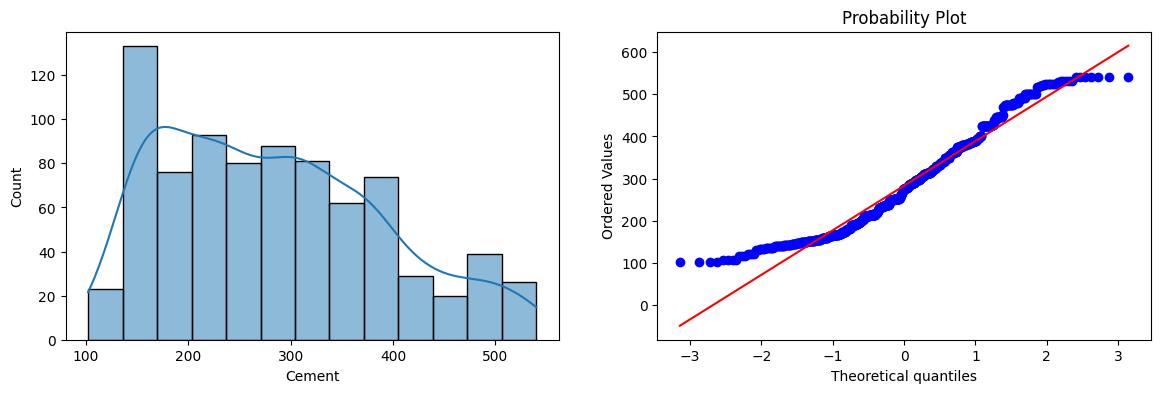

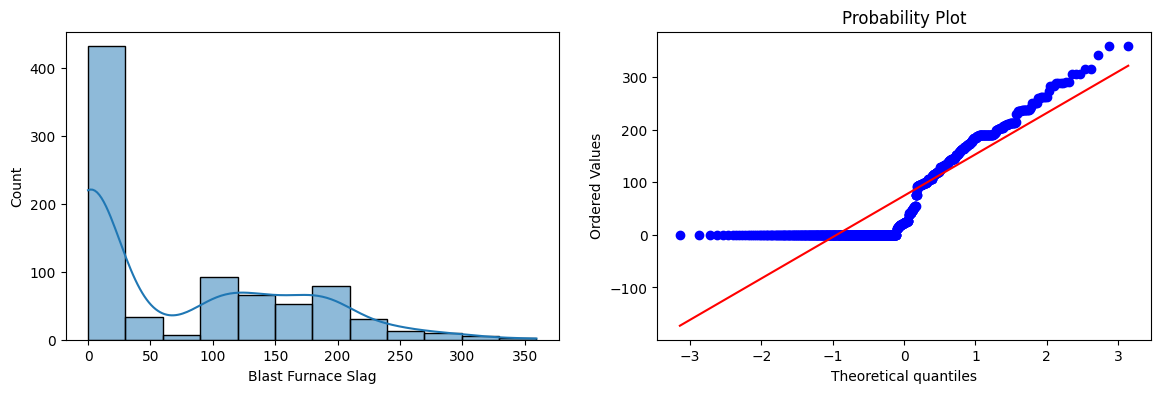

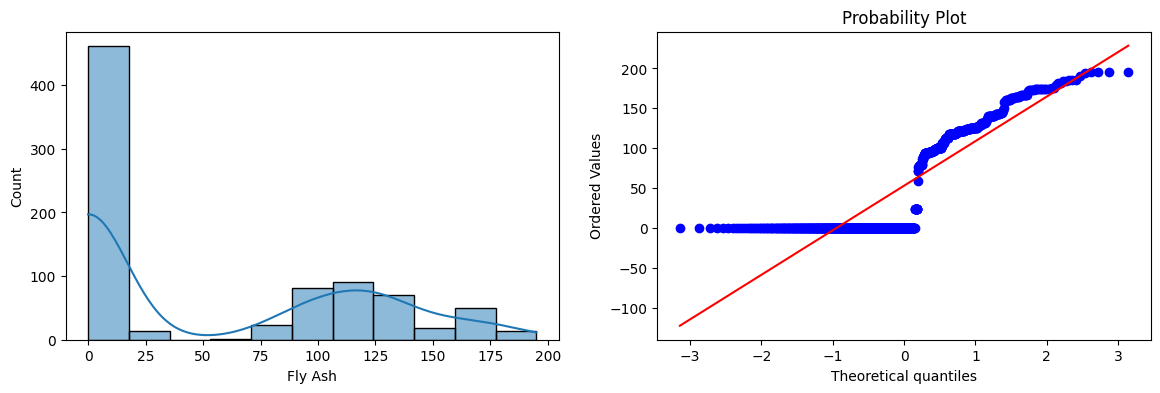

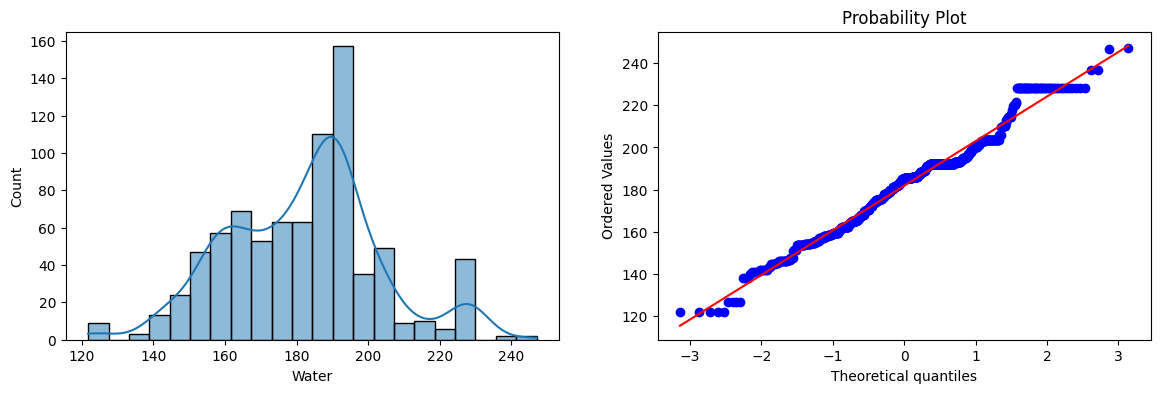

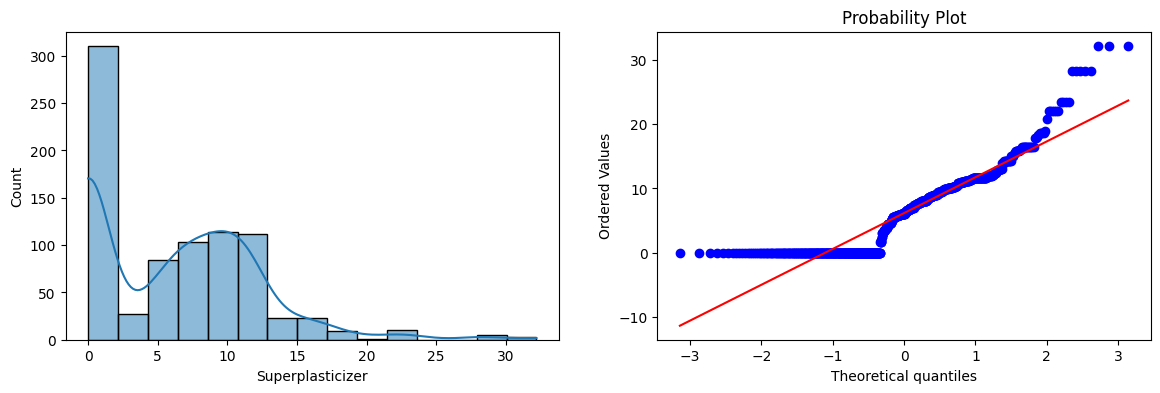

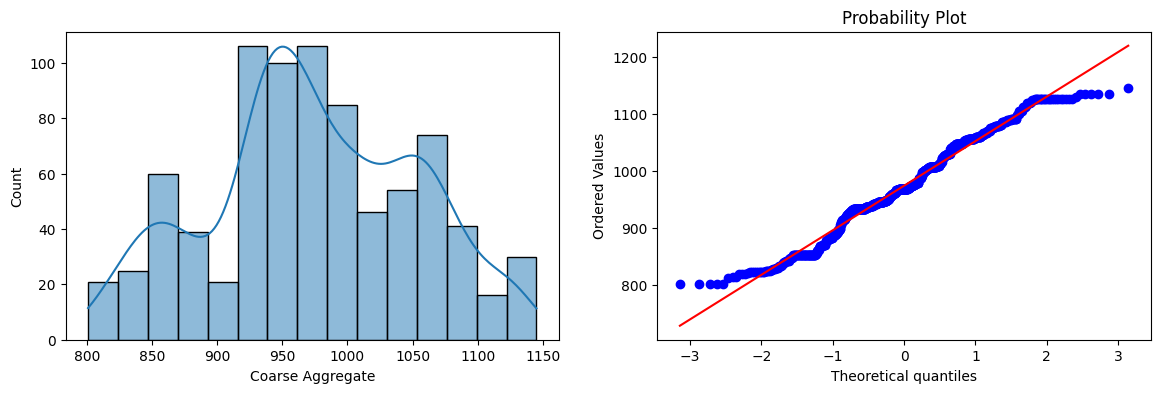

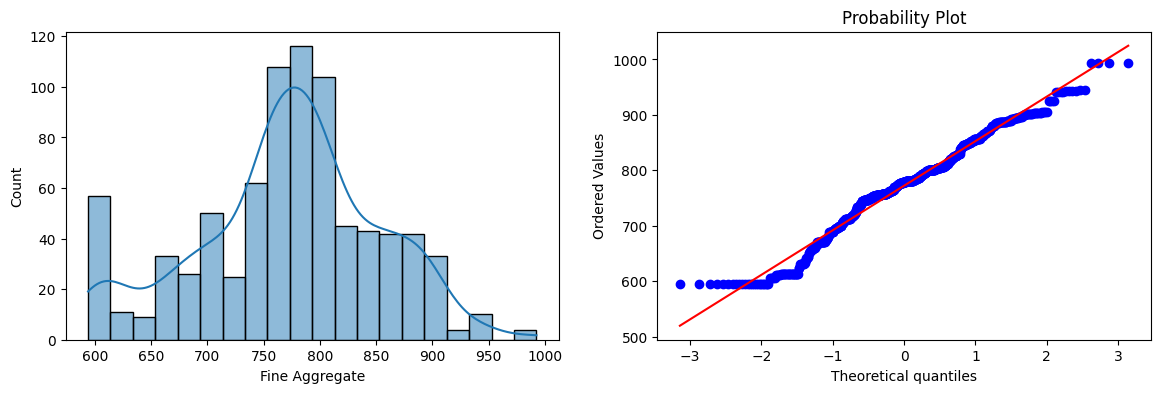

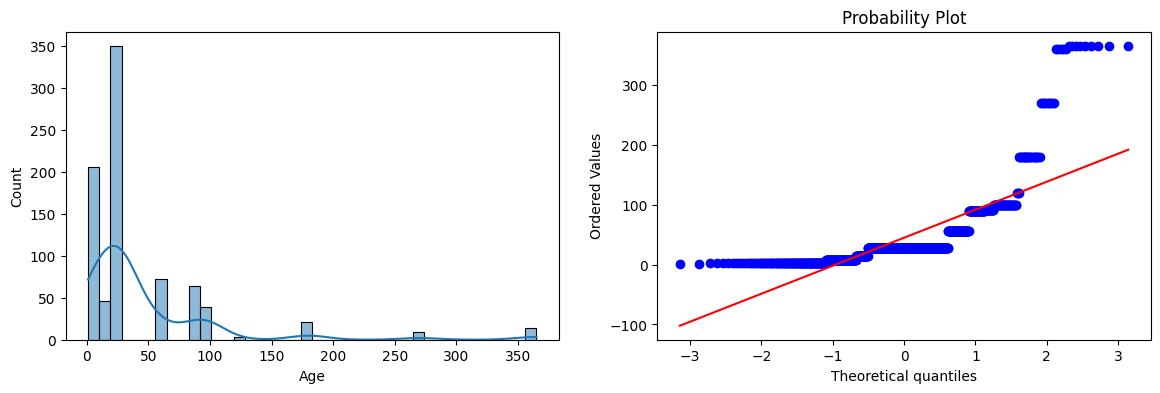

In [44]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(X_train[col], kde = True)

    plt.subplot(1,2,2)
    stats.probplot(X_train[col], dist='norm', plot =plt)

    plt.show()

In [50]:
#Applying Box-Cox Transformation
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train + 0.00001)
# + 0.00001 coz box-cox doesn't accept 0 , but we have 0 in value
X_test_transformed = pt.transform(X_test +0.00001)

pd.DataFrame({
    'columns': X_train.columns,
    'lamda_values': pt.lambdas_
})

,columns,lamda_values
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,Fly Ash,-0.044554
3,Water,0.772682
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [51]:
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred2 = lr.predict(X_test_transformed)
r2_score(y_pred2, y_test)

0.7629312455798809

In [52]:
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform((df.drop('Strength', axis=1 ))+0.00001)

lr= LinearRegression()
print(np.mean(cross_val_score(lr, X_transformed,df.Strength, scoring='r2')))

0.6668489648058483


In [53]:
# Comparing before transformation and after transformation

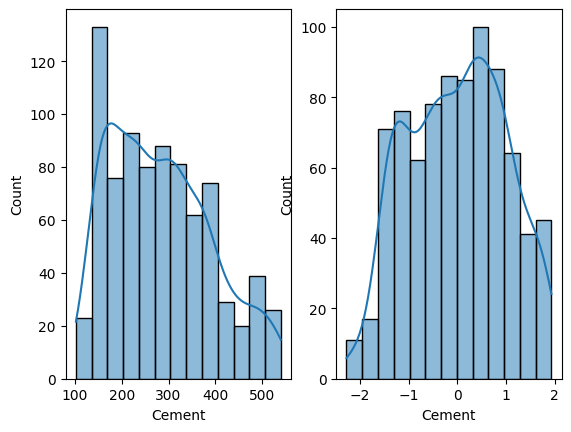

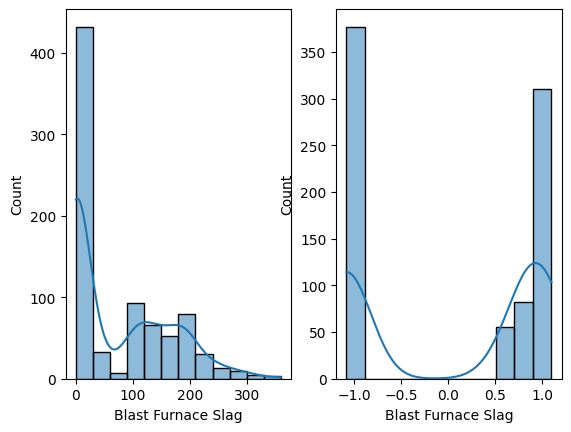

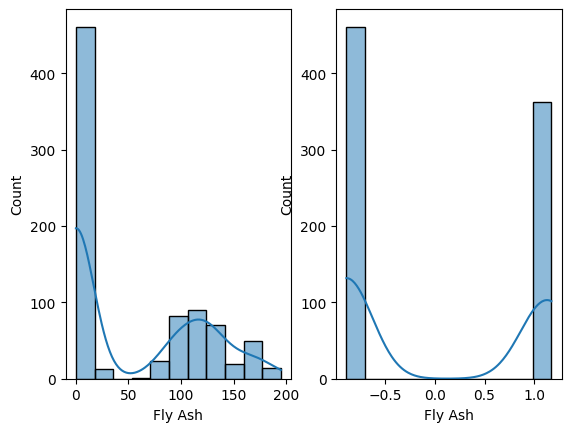

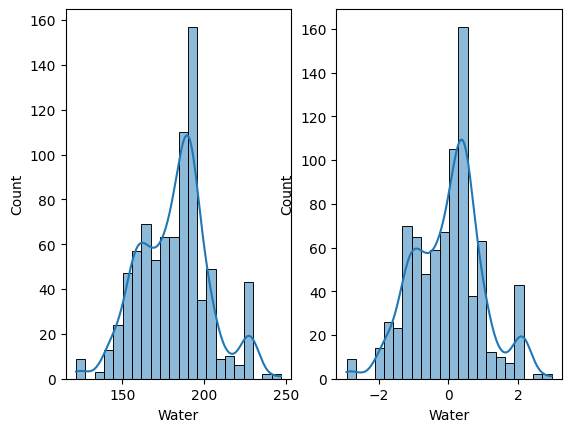

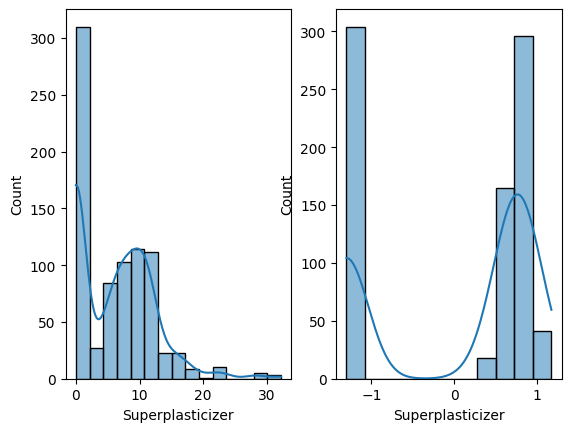

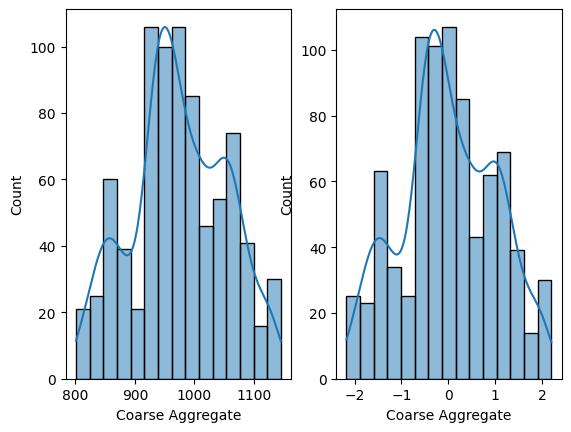

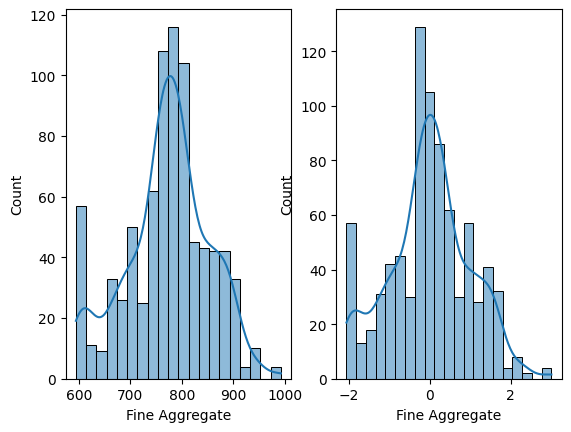

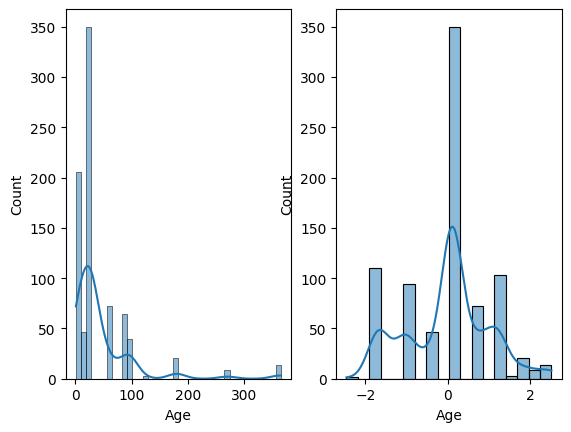

In [55]:
#X_train_transformed is numpy array hence need to be converted in pandas dataframe

X_train_transformed = pd.DataFrame(X_train_transformed, columns = X_train.columns)

for col in X_train_transformed.columns:

    plt.subplot(1,2,1)
    sns.histplot(X_train[col], kde= True)

    plt.subplot(1,2,2)
    sns.histplot(X_train_transformed[col], kde= True)

    plt.show()

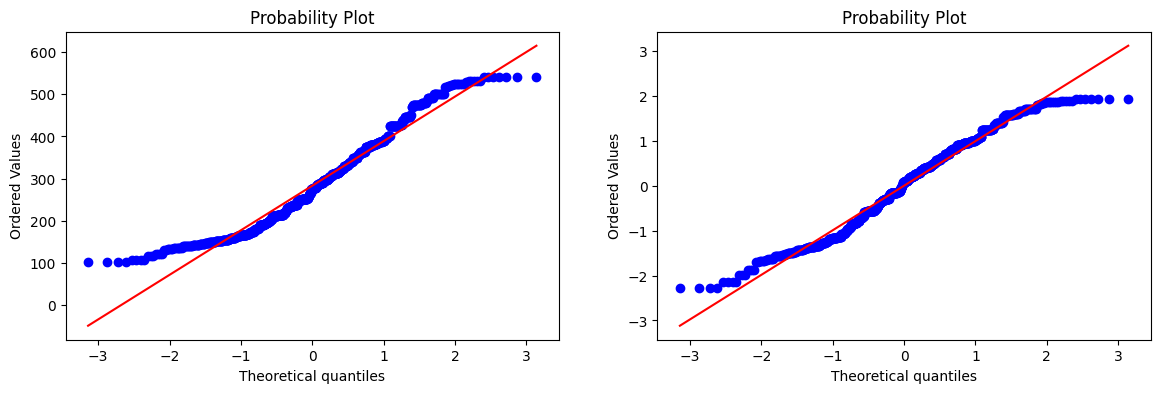

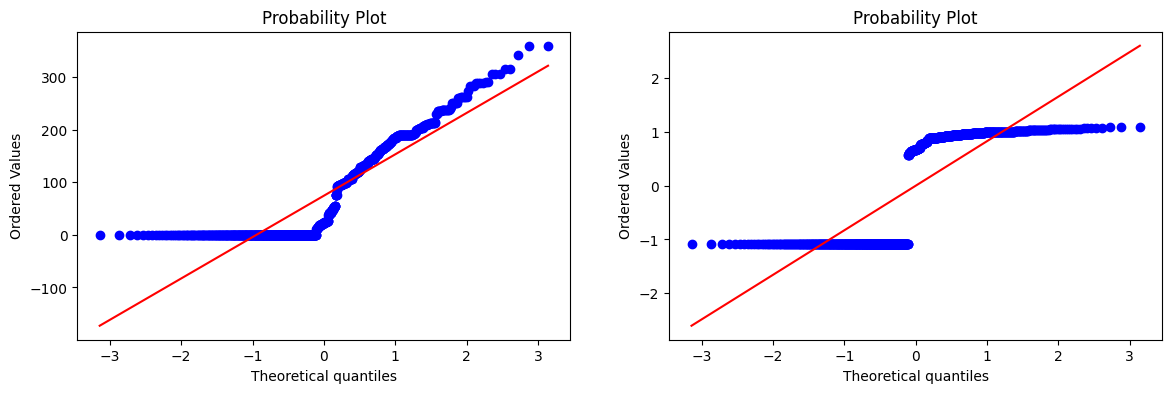

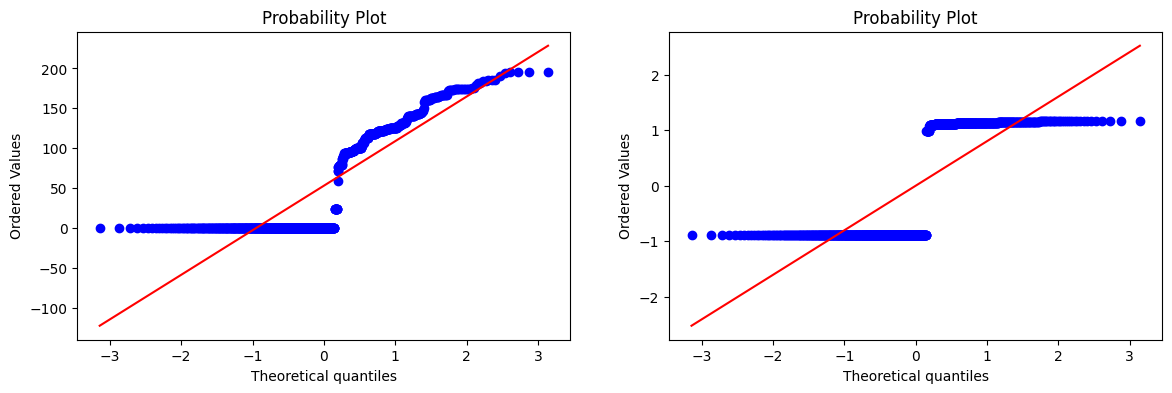

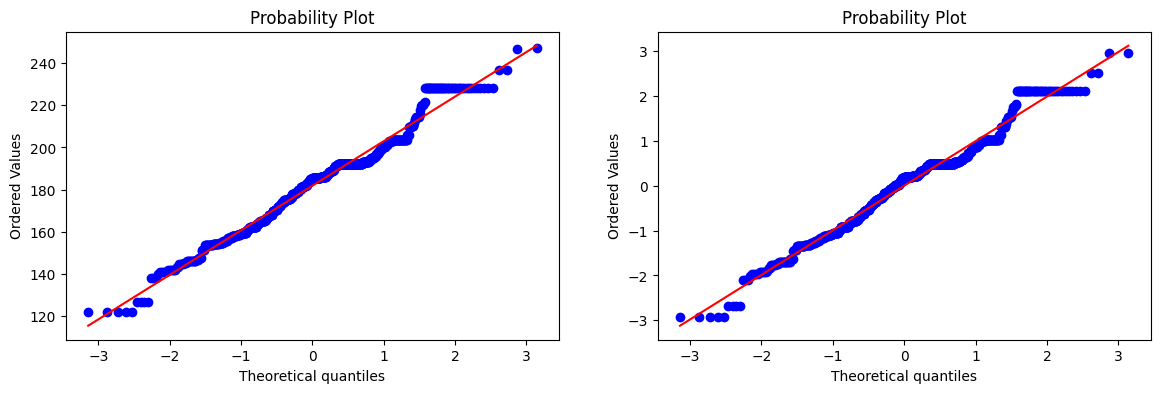

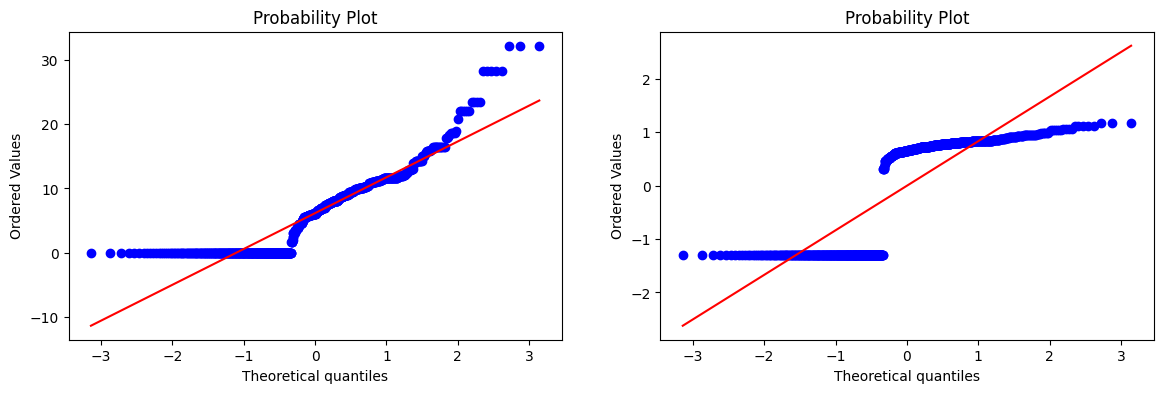

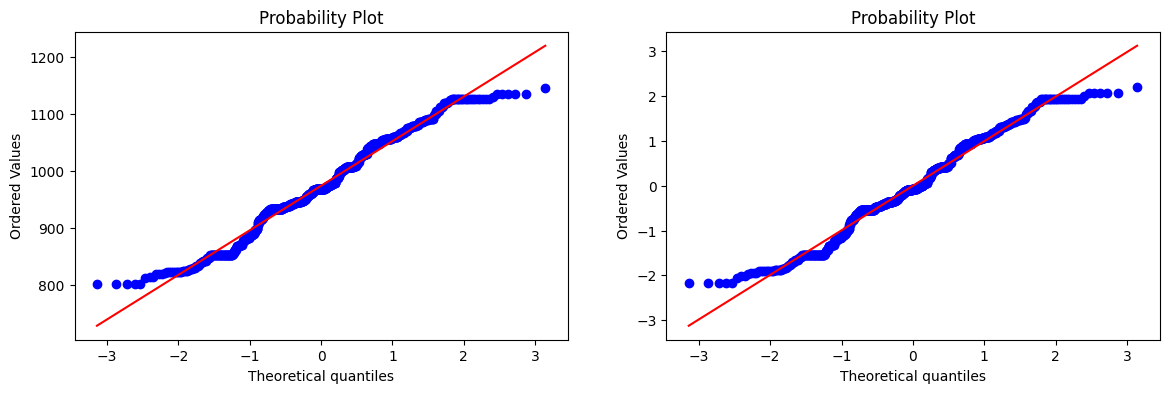

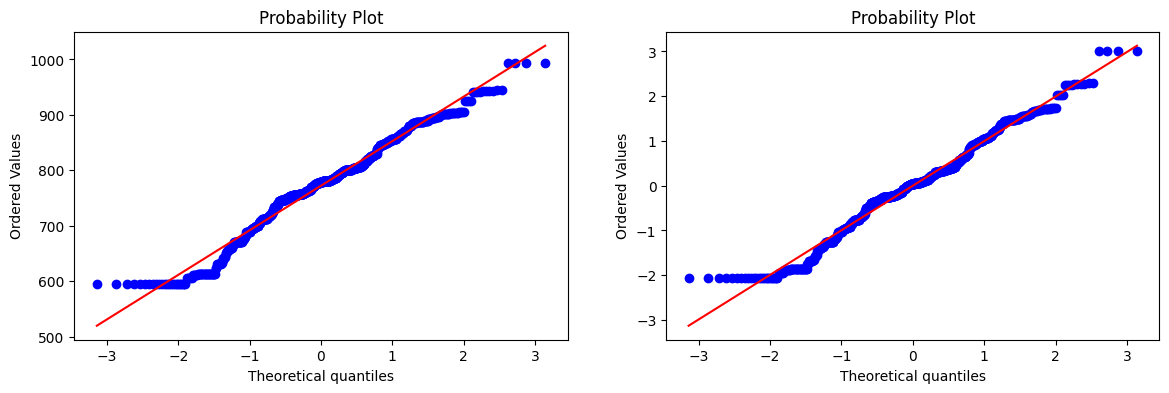

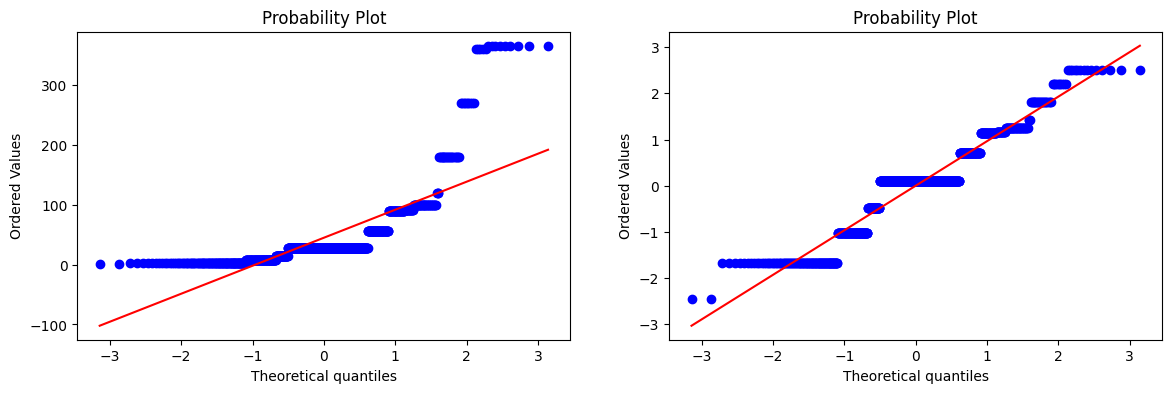

In [57]:
# before and after QQ PLOT

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    stats.probplot(X_train[col], dist = 'norm', plot =plt)

    plt.subplot(1,2,2)
    stats.probplot(X_train_transformed[col], dist= 'norm', plot= plt)

    plt.show()

In [58]:
#Yeo - Johnson

pt1= PowerTransformer()
X_train_transformer = pt1.fit_transform(X_train)
X_test_transformer = pt1.transform(X_test)

lr= LinearRegression()
lr.fit(X_train_transformer, y_train)
y_pred = lr.predict(X_test_transformer)
r2_score(y_pred, y_test)

0.7797686947737688

In [64]:
#applying cross val score

pt= PowerTransformer()
X_transformed= pt.fit_transform(df.drop(columns=['Strength']))

lr= LinearRegression()
np.mean(cross_val_score(lr, X_transformed, df.Strength, scoring='r2'))

np.float64(0.6834625131982243)